# Simple Biopol LCA 
Simple LCA for CITA's biopolymer panel. Includes the following processes: 
- 3D printing the panel 
- Pea protein binder
- Hemp dust filler
- Sea grass filler 

# Brightway project setup 

- A bw2 environment, project and database loaded with an ecoinvent copy need to be available in a separate local folder to be used by LcPy to derive the unit impacts of the sub-processes.
- be sure to use conda env `bw2`
- script was copied from [bw2 tutorial](https://learn.brightway.dev/en/latest/content/chapters/BW2/BW2_introduction.html#)

In [1]:
import bw2io as bi
import bw2data as bd
import bw2calc as bc
import pandas as pd 

In [2]:
print(list(bd.projects)) #the prefix "bd" indicates that "projects" is a method of the bw2data package
bd.projects.set_current('biopol_lca') # activates a project, or creates it first if it doesn't exist yet
# bd.projects.migrate_project_25() 
print(list(bd.databases)) # check if there are databases in the project, and how they are named. 

[Project: default, Project: RAW_Reblakk, Project: Reblakk_2ndTry, Project: OpenLCA_Conversion, Project: RAW_timber_structure, Project: RAW_timber_structure_apos, Project: biopol_lca, Project: dummy_project, Project: biopol_lca_backup_ecoinvent_v391]
['lca_database_3DPrintedBiopol', 'biosphere-3.12', 'ecoinvent-3.12-cutoff']


In [3]:
bi.utils.DEFAULT_REQUEST_TIMEOUT = 600  # 600 seconds = 10 minutes

if 'ecoinvent-3.12-cutoff' in bd.databases:
    print('ecoinvent 3.12 is already present in the project')
else:
    bi.import_ecoinvent_release(
        version='3.12',
        system_model='cutoff', # can be cutoff / apos / consequential / EN15804
        username='LUCML',
        password='ecoV3JG62,0'
    )

ecoinvent 3.12 is already present in the project


# Add activities in activity-browser
The main processes are being added using the GUI activity-browser. See [MURAL board](https://app.mural.co/t/phd8054/m/phd8054/1756974417787/814130911a62286de97df9a05934b4ede2e1108f) for progress

# Calculate flow amounts
Calculate technosphere input flows based on assumptions, explicitly shown below in Python code

In [4]:
[node for node in bd.Database('lca_database_3DPrintedBiopol')]

['centrifugation' (kilogram, GLO, None),
 '3D printing' (kilogram, RER, None),
 'seagrass filler production' (kilogram, GLO, None),
 'pea protein binder production' (kilogram, GLO, None),
 'hemp dust filler production' (kilogram, GLO, None),
 'milling' (kilogram, GLO, None),
 'membrane filtration' (kilogram, GLO, None),
 'aqueous mixing' (kilogram, GLO, None),
 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None),
 'Drying with dehumidifying chamber' (kilogram, RER, None)]

## Drying

In [5]:
# AMOUNTS FOR DRYING PROCESS

# base assumptions 
kg_output = 1 # kg of dry panel that we want to produce
hrs_drying = 2 * 7 * 24 # 2 weeks of drying time, in hours
kg_per_panel = 3 # weight of one wet panel in kg
n_panels_per_chamber = 10 # number of wet panels that can be dried in one chamber at the same time

# kg of baked panel that needs to be dried
kg_wetPanel_perKg_dryPanel = kg_output * 1.2 # kg of wet panel needed to produce 1 kg of dry panel
print(f'kg of wet panel needed to produce {kg_output} kg of dry panel: {kg_wetPanel_perKg_dryPanel} kg')

# kwh of electricity 
kwh_perHr_dehumidifier = 0.6 # kwh per hour of running the dehumidifier, based on the specifications of a commercial dehumidifier
kwh_electricity_perChamber = kwh_perHr_dehumidifier * hrs_drying
kg_wetPanel_perChamber = n_panels_per_chamber * kg_per_panel # kg of wet panel that can be dried in one chamber in 2 weeks
kwh_electricity_perKg_dryPanel = kwh_electricity_perChamber / (kg_wetPanel_perChamber / kg_wetPanel_perKg_dryPanel)
print(f'kwh of electricity needed to dry {kg_output} kg of dry panel: {kwh_electricity_perKg_dryPanel} kwh')

# units of dehumidifier 
hrs_lifetime_dehumidifier = 25 * 365 * 24 # 25 years of lifetime, in hours
units_dehumidifier_perKg_dryPanel = (hrs_drying / hrs_lifetime_dehumidifier) / (kg_wetPanel_perChamber / kg_wetPanel_perKg_dryPanel)
print(f'units of dehumidifier needed to dry {kg_output} kg of dry panel: {units_dehumidifier_perKg_dryPanel} units')

# save amounts in bw database
def modify_amounts(node, input_name, amount):
    edge = [edge for edge in node.edges() if input_name in edge.input['name']][0]
    edge['amount'] = amount # output is 1kg of 3D printed biopol 
    edge.save()

input_amounts = {
    'Kiln baking - 150 degress for 2 hours': kg_wetPanel_perKg_dryPanel, 
    'market for electricity, medium voltage': kwh_electricity_perKg_dryPanel, 
    'blower and heat exchange unit production, decentralized, 180-250 m3/h': units_dehumidifier_perKg_dryPanel,  
}

node_drying = bd.get_node(name='Drying with dehumidifying chamber', database='lca_database_3DPrintedBiopol')
for input_name, amount in input_amounts.items():
    modify_amounts(node_drying, input_name, amount)
list(node_drying.technosphere()) # check if the changes have been applied correctly
# [edge for edge in node_drying.edges()] # print all edges of a node 

kg of wet panel needed to produce 1 kg of dry panel: 1.2 kg
kwh of electricity needed to dry 1 kg of dry panel: 8.064 kwh
units of dehumidifier needed to dry 1 kg of dry panel: 6.136986301369863e-05 units


[Exchange: 1.2 kilogram 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None) to 'Drying with dehumidifying chamber' (kilogram, RER, None)>,
 Exchange: 6.136986301369863e-05 unit 'blower and heat exchange unit production, decentralized, 180-250 m3/h' (unit, RER, None) to 'Drying with dehumidifying chamber' (kilogram, RER, None)>,
 Exchange: 8.064 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'Drying with dehumidifying chamber' (kilogram, RER, None)>]

## Baking

In [6]:
# AMOUNTS FOR BAKING PROCESS

# base assumptions
kg_output = 1  # kg of baked panel that we want to produce
hrs_baking = 2  # 2 hours baking time at 150°C
kg_per_panel = 3.5  # weight of one wet panel in kg
n_panels_per_kiln = 3  # number of panels that fit in the kiln at once

# kg of wet panel that needs to be baked
# assumption: baking drives off moisture, panels lose ~10% of weight
kg_wetPanel_perKg_bakedPanel = kg_output * 1.1  # kg of wet panel needed to produce 1 kg of baked panel
print(f'kg of wet panel needed to produce {kg_output} kg of baked panel: {kg_wetPanel_perKg_bakedPanel} kg')

# kwh of electricity
# assumption: mid-sized light industrial kiln, estimated at 5 kW average draw during baking cycle
# note: kilns do not draw peak power continuously — heating elements cycle on/off to maintain
# temperature, so average draw is typically 50-70% of rated power. 5 kW is a conservative
# midpoint for a unit rated at ~6-8 kW.
kwh_perHr_kiln = 5  # kWh per hour, estimated for mid-sized light industrial kiln
kg_wetPanel_perKiln = n_panels_per_kiln * kg_per_panel  # kg of wet panel per kiln load
kwh_electricity_perBatch = kwh_perHr_kiln * hrs_baking  # kWh per baking batch
kwh_electricity_perKg_bakedPanel = kwh_electricity_perBatch / (kg_wetPanel_perKiln / kg_wetPanel_perKg_bakedPanel)
print(f'kwh of electricity needed to bake {kg_output} kg of baked panel: {kwh_electricity_perKg_bakedPanel} kwh')

# units of kiln
# baking is a batch process, so we allocate by number of batches rather than continuous hours
hrs_lifetime_kiln = 25 * 365 * 24  # 25 years of lifetime, in hours
hrs_kiln_perKg_bakedPanel = hrs_baking / (kg_wetPanel_perKiln / kg_wetPanel_perKg_bakedPanel)  # kiln-hours per kg output
units_kiln_perKg_bakedPanel = hrs_kiln_perKg_bakedPanel / hrs_lifetime_kiln
print(f'units of kiln needed to bake {kg_output} kg of baked panel: {units_kiln_perKg_bakedPanel} units')

# save amounts in bw database
node_baking = bd.get_node(name='Kiln baking - 150 degress for 2 hours', database='lca_database_3DPrintedBiopol')
input_amounts = {
    '3D printing': kg_wetPanel_perKg_bakedPanel,
    'market for electricity, medium voltage': kwh_electricity_perKg_bakedPanel,
    'market for industrial furnace, natural gas': units_kiln_perKg_bakedPanel,
}
for input_name, amount in input_amounts.items():
    modify_amounts(node_baking, input_name, amount)
list(node_baking.technosphere())  # check if the changes have been applied correctly

kg of wet panel needed to produce 1 kg of baked panel: 1.1 kg
kwh of electricity needed to bake 1 kg of baked panel: 1.0476190476190477 kwh
units of kiln needed to bake 1 kg of baked panel: 9.567297238530115e-07 units


[Exchange: 1.1 kilogram '3D printing' (kilogram, RER, None) to 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None)>,
 Exchange: 1.0476190476190477 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None)>,
 Exchange: 9.567297238530115e-07 unit 'market for industrial furnace, natural gas' (unit, GLO, None) to 'Kiln baking - 150 degress for 2 hours' (kilogram, RER, None)>]

## 3D printing

In [7]:
# AMOUNTS FOR 3D PRINTING PROCESS

# base assumptions
kg_output = 1  # kg of 3D printed wet panel that we want to produce
kg_per_panel = 3.5  # weight of one 3D printed wet panel in kg (consistent with baking process)
hrs_printing_per_panel = 4  # estimated print time per panel for a medium-sized panel on an ABB robotic arm
# note: mid-point of 2-6 hr range for a medium panel; should be updated if measured print time becomes available

# kwh of electricity
# assumption: medium duty ABB robotic arm setup estimated at 5 kW average draw during printing
# this includes the robotic arm motors, extruder, and any heating components
# note: similar to the kiln, average draw is typically 60-70% of peak rated power
kwh_perHr_printer = 5  # kWh per hour, estimated for medium duty robotic arm setup
kwh_electricity_perPanel = kwh_perHr_printer * hrs_printing_per_panel  # kWh per panel
kwh_electricity_perKg_wetPanel = kwh_electricity_perPanel / kg_per_panel
print(f'kwh of electricity needed to print {kg_output} kg of wet panel: {kwh_electricity_perKg_wetPanel} kwh')

# kg of 3D printer
# printing is a batch process (one panel at a time), so we allocate by print-hours per kg output
kg_printer = 1000  # kg of printer per unit, estimated based on a medium-sized industrial robotic arm setup
hrs_lifetime_printer = 25 * 365 * 24  # 25 years of lifetime, in hours
hrs_printer_perKg_wetPanel = hrs_printing_per_panel / kg_per_panel  # printer-hours per kg output
units_printer_perKg_wetPanel = hrs_printer_perKg_wetPanel / hrs_lifetime_printer
kg_printer_perKg_wetPanel = units_printer_perKg_wetPanel * kg_printer
print(f'kg of 3D printer needed to print {kg_output} kg of wet panel: {kg_printer_perKg_wetPanel} kg')

# save amounts in bw database
node_printing = bd.get_node(name='3D printing', database='lca_database_3DPrintedBiopol')
input_amounts = {
    'market for electricity, medium voltage': kwh_electricity_perKg_wetPanel,
    'industrial machine production, heavy, unspecified': kg_printer_perKg_wetPanel,
    'pea protein binder production': 0.5, 
    'hemp dust filler production': 0.3, 
    'seagrass filler production': 0.2
}
for input_name, amount in input_amounts.items():
    modify_amounts(node_printing, input_name, amount)
list(node_printing.technosphere())  # check if the changes have been applied correctly

kwh of electricity needed to print 1 kg of wet panel: 5.714285714285714 kwh
kg of 3D printer needed to print 1 kg of wet panel: 0.005218525766470972 kg


[Exchange: 5.714285714285714 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.005218525766470972 kilogram 'industrial machine production, heavy, unspecified' (kilogram, RER, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.3 kilogram 'hemp dust filler production' (kilogram, GLO, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.5 kilogram 'pea protein binder production' (kilogram, GLO, None) to '3D printing' (kilogram, RER, None)>,
 Exchange: 0.2 kilogram 'seagrass filler production' (kilogram, GLO, None) to '3D printing' (kilogram, RER, None)>]

## Transportation 

In [8]:
def calculate_ton_km(km_distance, kg_material=1):
    ton_material = kg_material / 1000 # convert kg to tons
    ton_km = ton_material * km_distance
    return ton_km

travel_distances = {
    'pea protein binder production': 50,  # example distance in km
    'hemp dust filler production': 150,  # example distance in km
    'seagrass filler production': 500,  # example distance in km
}

for material_name, km_distance in travel_distances.items():
    node = bd.get_node(name=material_name, database='lca_database_3DPrintedBiopol')
    ton_km = calculate_ton_km(km_distance=km_distance, kg_material=1)
    modify_amounts(node, 'market for transport, freight, lorry, unspecified', ton_km)
    print(material_name)
    for edge in node.technosphere(): 
        print(edge)
    print('')

pea protein binder production
Exchange: 0.05 ton kilometer 'market for transport, freight, lorry, unspecified' (ton kilometer, RER, None) to 'pea protein binder production' (kilogram, GLO, None)>
Exchange: 1 kilogram 'membrane filtration' (kilogram, GLO, None) to 'pea protein binder production' (kilogram, GLO, None)>

hemp dust filler production
Exchange: 1 kilogram 'carding waste, hemp to generic market for cellulose fibre' (kilogram, FR, None) to 'hemp dust filler production' (kilogram, GLO, None)>
Exchange: 0.15 ton kilometer 'market for transport, freight, lorry, unspecified' (ton kilometer, RER, None) to 'hemp dust filler production' (kilogram, GLO, None)>

seagrass filler production
Exchange: 1 kilogram 'flax straw production, dew-retted' (kilogram, RER, None) to 'seagrass filler production' (kilogram, GLO, None)>
Exchange: 0.5 ton kilometer 'market for transport, freight, lorry, unspecified' (ton kilometer, RER, None) to 'seagrass filler production' (kilogram, GLO, None)>



## Pea protein production

In [9]:
# function for calculating kwh energy for chemical production process
def calculate_kwh_electricity(hrs_process, kwh_perHr, machine_capacity_kg=1000):
    kwh_electricity_perMachine = hrs_process * kwh_perHr
    kwh_electricity = kwh_electricity_perMachine / machine_capacity_kg
    return kwh_electricity

# function for calculating kg of machinery needed 
def calculate_kg_machinery(hrs_process, hrs_lifetime, kg_per_unit, machine_capacity_kg=1000):
    units_needed = hrs_process / hrs_lifetime
    kg_machinery = units_needed * kg_per_unit
    kg_machinery_perKg_material = kg_machinery / machine_capacity_kg
    return kg_machinery_perKg_material

assumptions_dict = {
    'membrane filtration': {
        'hrs_process': 3, 
        'kwh_perHr': 3,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 200, 
        'machine_capacity_kg': 500, 
    }, 
    'centrifugation': {
        'hrs_process': 2, 
        'kwh_perHr': 7,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 800, 
        'machine_capacity_kg': 500, 
    }, 
    'aqueous mixing': {
        'hrs_process': 4, 
        'kwh_perHr': 1.5,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 300, 
        'machine_capacity_kg': 500, 
    }, 
    'milling': {
        'hrs_process': 2, 
        'kwh_perHr': 10,
        'hrs_lifetime': 25 * 365 * 24,
        'kg_per_unit': 1000, 
        'machine_capacity_kg': 500, 
    }, 
}

for process_name, assumptions in assumptions_dict.items():
    node = bd.get_node(name=process_name, database='lca_database_3DPrintedBiopol')
    kwh_electricity = calculate_kwh_electricity(hrs_process=assumptions['hrs_process'], kwh_perHr=assumptions['kwh_perHr'], machine_capacity_kg=assumptions['machine_capacity_kg'])
    kg_machinery = calculate_kg_machinery(hrs_process=assumptions['hrs_process'], hrs_lifetime=assumptions['hrs_lifetime'], kg_per_unit=assumptions['kg_per_unit'], machine_capacity_kg=assumptions['machine_capacity_kg'])
    modify_amounts(node, 'electricity, medium voltage', kwh_electricity)
    modify_amounts(node, 'industrial machine, heavy, unspecified', kg_machinery)
    print(process_name)
    for edge in node.technosphere():
        print(edge)


membrane filtration
Exchange: 1 kilogram 'centrifugation' (kilogram, GLO, None) to 'membrane filtration' (kilogram, GLO, None)>
Exchange: 0.018 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'membrane filtration' (kilogram, GLO, None)>
Exchange: 5.479452054794521e-06 kilogram 'market for industrial machine, heavy, unspecified' (kilogram, RER, None) to 'membrane filtration' (kilogram, GLO, None)>
centrifugation
Exchange: 1 kilogram 'aqueous mixing' (kilogram, GLO, None) to 'centrifugation' (kilogram, GLO, None)>
Exchange: 0.028 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, DE, None) to 'centrifugation' (kilogram, GLO, None)>
Exchange: 1.4611872146118723e-05 kilogram 'market for industrial machine, heavy, unspecified' (kilogram, RER, None) to 'centrifugation' (kilogram, GLO, None)>
aqueous mixing
Exchange: 1 kilogram 'milling' (kilogram, GLO, None) to 'aqueous mixing' (kilogram, GLO, None)>
Exchange: 1 kilogram 'market for pro

# LCIA

In [10]:
# select method for LCA calculation
list(bd.methods)
cml_methods = [method for method in bd.methods if method[0] == 'CML v4.8 2016 no LT']
cml_gwp_key = [method for method in cml_methods if 'global warming' in method[2]].pop() 
cml_gwp_key

('CML v4.8 2016 no LT',
 'climate change no LT',
 'global warming potential (GWP100) no LT')

In [11]:
cml_methods[1]

('CML v4.8 2016 no LT',
 'climate change no LT',
 'global warming potential (GWP100) no LT')

In [12]:
# calculate all activities using all methods in cml_methods 
db = bd.Database('lca_database_3DPrintedBiopol')

# print overview of activities 
print('summary of activities in our database:')
for act in db: 
    name = act['name']
    id = db.get(name=name).id
    print(f'{id} - {name}')

# define functional units and methods for multi-LCA calculation
functional_units = {}
for act in db: 
    name = act['name']
    id = db.get(name=name).id
    functional_units[name] = {db.get(name=name).id:1}
config = {'impact_categories': [cml_methods[1]]}
data_objs = bd.get_multilca_data_objs(functional_units=functional_units, method_config=config)

# calculate multi-LCA
mlca_2 = bc.MultiLCA(demands=functional_units, method_config=config, data_objs=data_objs)
mlca_2.lci()
mlca_2.lcia()

summary of activities in our database:
25958 - Kiln baking - 150 degress for 2 hours
310747495627898880 - aqueous mixing
310746682058752000 - membrane filtration
25957 - Drying with dehumidifying chamber
310744122832863232 - hemp dust filler production
310747592356937728 - milling
310717486095810560 - pea protein binder production
310744071972732928 - seagrass filler production
310747240719073280 - centrifugation
25959 - 3D printing


In [13]:
# visualize results

# create dataframe with results
dfresults = pd.DataFrame.from_dict(mlca_2.scores, orient='index')
dfresults.index = pd.MultiIndex.from_tuples(dfresults.index, names=['Column', 'Row'])
dfresults = dfresults.unstack(level=0)
dfresults

# # make bar chart
# import matplotlib.pyplot as plt
# dfresults.plot(kind="barh")
# ax = plt.subplot(111)
# box = ax.get_position()
# ax.set_position([box.x0, box.y0 + box.height, box.width, box.height])
# ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
# plt.show()

,0
Column,"(CML v4.8 2016 no LT, climate change no LT, global warming potential (GWP100) no LT)"
Row,
3D printing,3.302830
Drying with dehumidifying chamber,9.205164
Kiln baking - 150 degress for 2 hours,4.186484
aqueous mixing,0.430776
centrifugation,0.445272
hemp dust filler production,0.164348
membrane filtration,0.454581
milling,0.020702


In [14]:
# basic contribution analysis 
import bw2analyzer as bwa
ca = bwa.utils.recursive_calculation_to_object(
    db.get(name='Drying with dehumidifying chamber'),
    cml_methods[1],
    amount=1,  # How much of the activity? (same as in our FU)
    max_level=5,  # How many levels deep in the CA do you want to go?
)
ca = pd.DataFrame(ca)
ca.head() 

,label,parent,score,fraction,amount,name,key
0,root,None,9.205164,1.000000,1.000000,Drying with dehumidifying chamber,"(lca_database_3DPrintedBiopol, f81ed13fd5614c9..."
1,root_a,root,5.023781,0.545757,1.200000,Kiln baking - 150 degress for 2 hours,"(lca_database_3DPrintedBiopol, f71ee748eecf4b6..."
2,root_a_a,root_a,4.359735,0.473618,1.320000,3D printing,"(lca_database_3DPrintedBiopol, b8fd832602d2463..."
3,root_a_a_a,root_a_a,3.895041,0.423136,7.542857,"market for electricity, medium voltage","(ecoinvent-3.12-cutoff, 2bf03d6f26170fb34a9a28..."
4,root_a_a_a_b,root_a_a_a,3.865223,0.419897,7.367562,electricity voltage transformation from high t...,"(ecoinvent-3.12-cutoff, cc0b114d5860e380a3df0f..."


In [15]:
import plotly.graph_objects as go
import pandas as pd

# --- build node and link lists for Sankey ---
labels = ca["label"].tolist()
label_to_idx = {l: i for i, l in enumerate(labels)}

# short display names (truncate long ecoinvent names)
def short_name(name, maxlen=30):
    return name if len(name) <= maxlen else name[:maxlen] + "…"

display_names = [short_name(row["name"]) + f"<br>{row['score']:.5f} kg CO₂eq"
                 for _, row in ca.iterrows()]

sources, targets, values, link_labels = [], [], [], []

for _, row in ca.iterrows():
    if row["parent"] is None:
        continue
    src = label_to_idx[row["label"]]      # child → parent (reversed)
    tgt = label_to_idx[row["parent"]]
    sources.append(src)
    targets.append(tgt)
    values.append(row["score"])
    link_labels.append(
        f"{short_name(row['name'], 25)} → "
        f"{ca.loc[ca.label==row['parent'], 'name'].values[0][:25]}<br>"
        f"{row['score']:.5f} kg CO₂eq ({row['fraction']*100:.1f}%)"
    )

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="grey", width=0.5),
        label=display_names,
        color="#000000",
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        label=link_labels,
        color="rgba(150,150,150,0.25)",
    ),
))

fig.update_layout(
    title=dict(
        text="LCA acidification impacts — Drying with dehumidifying chamber<br>"
             "<sup>CML v4.8 2016 | kg CO₂eq | hover nodes and flows for details</sup>",
        font_size=14,
    ),
    font_size=11,
    height=500,
)

fig.show()

In [16]:
import plotly.graph_objects as go
import pandas as pd

# --- define cutoff nodes: anything upstream of these will be hidden ---
cutoff_names = {
    'market for electricity, medium voltage',
    'market for electricity, high voltage',
    'electricity voltage transformation from high to medium voltage',
    # add any other names you want to treat as terminal nodes
}

# find the labels corresponding to cutoff nodes
cutoff_labels = set(ca.loc[ca["name"].isin(cutoff_names), "label"])

# keep only rows that are NOT upstream of a cutoff node
# i.e. drop any row whose parent label is in cutoff_labels
ca_filtered = ca[~ca["parent"].isin(cutoff_labels)].copy()

# --- build node and link lists from filtered dataframe ---
labels = ca_filtered["label"].tolist()
label_to_idx = {l: i for i, l in enumerate(labels)}

def short_name(name, maxlen=30):
    return name if len(name) <= maxlen else name[:maxlen] + "…"

display_names = [short_name(row["name"]) + f"<br>{row['score']:.5f} kg CO₂eq"
                 for _, row in ca_filtered.iterrows()]

sources, targets, values, link_labels = [], [], [], []

for _, row in ca_filtered.iterrows():
    if row["parent"] is None or row["parent"] not in label_to_idx:
        continue
    src = label_to_idx[row["label"]]
    tgt = label_to_idx[row["parent"]]
    sources.append(src)
    targets.append(tgt)
    values.append(row["score"])
    link_labels.append(
        f"{short_name(row['name'], 25)} → "
        f"{ca_filtered.loc[ca_filtered.label==row['parent'], 'name'].values[0][:25]}<br>"
        f"{row['score']:.5f} kg CO₂eq ({row['fraction']*100:.1f}%)"
    )

fig = go.Figure(go.Sankey(
    arrangement="perpendicular",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="grey", width=0.5),
        label=display_names,
        color="#000000",
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        label=link_labels,
        color="rgba(150,150,150,0.25)",
    ),
))

fig.update_layout(
    title=dict(
        text="LCA GWP impacts — Drying with dehumidifying chamber<br>"
             "<sup>CML v4.8 2016 | kg CO₂eq | hover nodes and flows for details</sup>",
        font_size=14,
    ),
    font_size=11,
    height=500,
)

fig.show()

# Sensitivity analysis 

In [17]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bw2data as bd
import bw2calc as bc

DB_NAME = 'lca_database_3DPrintedBiopol'

# ── BASE ASSUMPTIONS ────────────────────────────────────────────────────────
# These mirror the variables scattered across your earlier cells.
# All sensitivity analysis is done by varying these values.

BASE_ASSUMPTIONS = {

    # ── DRYING ──────────────────────────────────────────────────────────────
    'drying_weeks':              2,      # weeks of drying time
    'drying_kg_per_panel':       3,      # kg per wet panel
    'drying_n_panels_chamber':   10,     # panels per chamber
    'drying_kwh_perHr':          0.6,    # kWh/hr dehumidifier draw
    'drying_lifetime_yrs':       25,     # dehumidifier lifetime in years

    # ── BAKING ──────────────────────────────────────────────────────────────
    'baking_hrs':                2,      # hours in kiln
    'baking_kg_per_panel':       3.5,    # kg per wet panel
    'baking_n_panels_kiln':      3,      # panels per kiln load
    'baking_kwh_perHr':          5,      # kWh/hr kiln draw
    'baking_lifetime_yrs':       25,     # kiln lifetime in years

    # ── 3D PRINTING ─────────────────────────────────────────────────────────
    'printing_kg_per_panel':     3.5,    # kg per wet panel
    'printing_hrs_per_panel':    4,      # print time per panel
    'printing_kwh_perHr':        5,      # kWh/hr printer draw
    'printing_kg_printer':       1000,   # mass of printer unit in kg
    'printing_lifetime_yrs':     25,     # printer lifetime in years

    # ── TRANSPORT (km distances) ─────────────────────────────────────────────
    'transport_km_pea':          50,
    'transport_km_hemp':         150,
    'transport_km_seagrass':     500,

    # ── PEA PROTEIN SUB-PROCESSES ────────────────────────────────────────────
    # Each sub-process: hrs_process, kwh_perHr, kg_per_unit, machine_capacity_kg
    'membfilt_hrs':              3,
    'membfilt_kwh_perHr':        3,
    'membfilt_kg_per_unit':      200,
    'membfilt_capacity_kg':      500,

    'centrif_hrs':               2,
    'centrif_kwh_perHr':         7,
    'centrif_kg_per_unit':       800,
    'centrif_capacity_kg':       500,

    'mixing_hrs':                4,
    'mixing_kwh_perHr':          1.5,
    'mixing_kg_per_unit':        300,
    'mixing_capacity_kg':        500,

    'milling_hrs':               2,
    'milling_kwh_perHr':         10,
    'milling_kg_per_unit':       1000,
    'milling_capacity_kg':       500,
}

# Human-readable labels for the tornado chart
ASSUMPTION_LABELS = {
    'drying_weeks':              'Drying: weeks of drying time',
    'drying_kg_per_panel':       'Drying: kg per wet panel',
    'drying_n_panels_chamber':   'Drying: panels per chamber',
    'drying_kwh_perHr':          'Drying: kWh/hr (dehumidifier)',
    'drying_lifetime_yrs':       'Drying: equipment lifetime (yrs)',
    'baking_hrs':                'Baking: hours in kiln',
    'baking_kg_per_panel':       'Baking: kg per wet panel',
    'baking_n_panels_kiln':      'Baking: panels per kiln load',
    'baking_kwh_perHr':          'Baking: kWh/hr (kiln)',
    'baking_lifetime_yrs':       'Baking: kiln lifetime (yrs)',
    'printing_kg_per_panel':     'Printing: kg per wet panel',
    'printing_hrs_per_panel':    'Printing: hours per panel',
    'printing_kwh_perHr':        'Printing: kWh/hr (printer)',
    'printing_kg_printer':       'Printing: printer mass (kg)',
    'printing_lifetime_yrs':     'Printing: printer lifetime (yrs)',
    'transport_km_pea':          'Transport: pea protein distance (km)',
    'transport_km_hemp':         'Transport: hemp distance (km)',
    'transport_km_seagrass':     'Transport: seagrass distance (km)',
    'membfilt_hrs':              'Membrane filtration: process hrs',
    'membfilt_kwh_perHr':        'Membrane filtration: kWh/hr',
    'membfilt_kg_per_unit':      'Membrane filtration: machine mass (kg)',
    'membfilt_capacity_kg':      'Membrane filtration: batch capacity (kg)',
    'centrif_hrs':               'Centrifugation: process hrs',
    'centrif_kwh_perHr':         'Centrifugation: kWh/hr',
    'centrif_kg_per_unit':       'Centrifugation: machine mass (kg)',
    'centrif_capacity_kg':       'Centrifugation: batch capacity (kg)',
    'mixing_hrs':                'Aqueous mixing: process hrs',
    'mixing_kwh_perHr':          'Aqueous mixing: kWh/hr',
    'mixing_kg_per_unit':        'Aqueous mixing: machine mass (kg)',
    'mixing_capacity_kg':        'Aqueous mixing: batch capacity (kg)',
    'milling_hrs':               'Milling: process hrs',
    'milling_kwh_perHr':         'Milling: kWh/hr',
    'milling_kg_per_unit':       'Milling: machine mass (kg)',
    'milling_capacity_kg':       'Milling: batch capacity (kg)',
}

In [18]:
def modify_amounts(node, input_name, amount):
    """Write a new amount to an exchange edge (reused from your existing code)."""
    edge = [e for e in node.edges() if input_name in e.input['name']][0]
    edge['amount'] = amount
    edge.save()


def compute_and_write_amounts(assumptions):
    """
    Derive all exchange amounts from the given assumptions dict,
    then write them to the brightway database.
    This consolidates all the calculation cells from your notebook.
    """
    a = assumptions  # shorthand

    LIFETIME_HRS = lambda yrs: yrs * 365 * 24

    # ── DRYING ──────────────────────────────────────────────────────────────
    hrs_drying = a['drying_weeks'] * 7 * 24
    kg_wetPanel_perKg_dryPanel = 1.2  # fixed physical constant (moisture loss)

    kg_wetPanel_perChamber = a['drying_n_panels_chamber'] * a['drying_kg_per_panel']
    ratio_drying = kg_wetPanel_perChamber / kg_wetPanel_perKg_dryPanel

    kwh_drying = (a['drying_kwh_perHr'] * hrs_drying) / ratio_drying
    units_dehumidifier = (hrs_drying / LIFETIME_HRS(a['drying_lifetime_yrs'])) / ratio_drying

    node_drying = bd.get_node(name='Drying with dehumidifying chamber', database=DB_NAME)
    modify_amounts(node_drying, 'Kiln baking - 150 degress for 2 hours', kg_wetPanel_perKg_dryPanel)
    modify_amounts(node_drying, 'market for electricity, medium voltage', kwh_drying)
    modify_amounts(node_drying, 'blower and heat exchange unit production, decentralized, 180-250 m3/h', units_dehumidifier)

    # ── BAKING ──────────────────────────────────────────────────────────────
    kg_wetPanel_perKg_bakedPanel = 1.1  # fixed physical constant (moisture loss)

    kg_wetPanel_perKiln = a['baking_n_panels_kiln'] * a['baking_kg_per_panel']
    ratio_baking = kg_wetPanel_perKiln / kg_wetPanel_perKg_bakedPanel

    kwh_baking = (a['baking_kwh_perHr'] * a['baking_hrs']) / ratio_baking
    hrs_kiln_perKg = a['baking_hrs'] / ratio_baking
    units_kiln = hrs_kiln_perKg / LIFETIME_HRS(a['baking_lifetime_yrs'])

    node_baking = bd.get_node(name='Kiln baking - 150 degress for 2 hours', database=DB_NAME)
    modify_amounts(node_baking, '3D printing', kg_wetPanel_perKg_bakedPanel)
    modify_amounts(node_baking, 'market for electricity, medium voltage', kwh_baking)
    modify_amounts(node_baking, 'market for industrial furnace, natural gas', units_kiln)

    # ── 3D PRINTING ─────────────────────────────────────────────────────────
    kwh_printing = (a['printing_kwh_perHr'] * a['printing_hrs_per_panel']) / a['printing_kg_per_panel']
    hrs_printer_perKg = a['printing_hrs_per_panel'] / a['printing_kg_per_panel']
    kg_printer_perKg = (hrs_printer_perKg / LIFETIME_HRS(a['printing_lifetime_yrs'])) * a['printing_kg_printer']

    node_printing = bd.get_node(name='3D printing', database=DB_NAME)
    modify_amounts(node_printing, 'market for electricity, medium voltage', kwh_printing)
    modify_amounts(node_printing, 'industrial machine production, heavy, unspecified', kg_printer_perKg)

    # ── TRANSPORT ────────────────────────────────────────────────────────────
    def ton_km(km): return km / 1000  # for 1 kg of material

    transport_nodes = {
        'pea protein binder production': a['transport_km_pea'],
        'hemp dust filler production':   a['transport_km_hemp'],
        'seagrass filler production':    a['transport_km_seagrass'],
    }
    for node_name, km in transport_nodes.items():
        node = bd.get_node(name=node_name, database=DB_NAME)
        modify_amounts(node, 'market for transport, freight, lorry, unspecified', ton_km(km))

    # ── PEA PROTEIN SUB-PROCESSES ────────────────────────────────────────────
    sub_processes = {
        'membrane filtration': {
            'hrs':      a['membfilt_hrs'],
            'kwh_perHr': a['membfilt_kwh_perHr'],
            'kg_unit':  a['membfilt_kg_per_unit'],
            'capacity': a['membfilt_capacity_kg'],
        },
        'centrifugation': {
            'hrs':      a['centrif_hrs'],
            'kwh_perHr': a['centrif_kwh_perHr'],
            'kg_unit':  a['centrif_kg_per_unit'],
            'capacity': a['centrif_capacity_kg'],
        },
        'aqueous mixing': {
            'hrs':      a['mixing_hrs'],
            'kwh_perHr': a['mixing_kwh_perHr'],
            'kg_unit':  a['mixing_kg_per_unit'],
            'capacity': a['mixing_capacity_kg'],
        },
        'milling': {
            'hrs':      a['milling_hrs'],
            'kwh_perHr': a['milling_kwh_perHr'],
            'kg_unit':  a['milling_kg_per_unit'],
            'capacity': a['milling_capacity_kg'],
        },
    }
    for node_name, p in sub_processes.items():
        node = bd.get_node(name=node_name, database=DB_NAME)
        kwh = (p['hrs'] * p['kwh_perHr']) / p['capacity']
        kg_mach = ((p['hrs'] / LIFETIME_HRS(25)) * p['kg_unit']) / p['capacity']
        modify_amounts(node, 'electricity, medium voltage', kwh)
        modify_amounts(node, 'industrial machine, heavy, unspecified', kg_mach)

In [22]:
# select method (reusing your existing approach)
cml_methods = [m for m in bd.methods if m[0] == 'CML v4.8 2016 no LT']
cml_gwp_key = [m for m in cml_methods if 'global warming' in m[2]].pop()

def run_lca(functional_unit_node_name='Drying with dehumidifying chamber'):
    """
    Run a single LCA for the given top-level node and return the total GWP score.
    
    Defaults to 'Drying with dehumidifying chamber' as the top-level process,
    since it encompasses the full chain (drying → baking → printing → materials).
    Change this if your system boundary is defined differently.
    """
    db = bd.Database(DB_NAME)
    node = db.get(name=functional_unit_node_name)
    fu = {node.id: 1}
    config = {'impact_categories': [cml_gwp_key]}
    data_objs = bd.get_multilca_data_objs(functional_units={functional_unit_node_name: fu}, method_config=config)
    mlca = bc.MultiLCA(demands={functional_unit_node_name: fu}, method_config=config, data_objs=data_objs)
    mlca.lci()
    mlca.lcia()
    return mlca.scores[(cml_gwp_key, functional_unit_node_name)]

In [23]:
VARIATION = 0.5   # ±50% — adjust as you like
N_STEPS   = 5     # number of steps each side of baseline (total: 2*N_STEPS + 1)

# ── Compute baseline ─────────────────────────────────────────────────────────
print('Computing baseline...')
compute_and_write_amounts(BASE_ASSUMPTIONS)
baseline_score = run_lca()
print(f'Baseline GWP: {baseline_score:.4f} kg CO₂eq')

# ── One-at-a-time sweep ──────────────────────────────────────────────────────
sensitivity_results = {}   # {param_key: {'low': score, 'high': score}}

for param_key, base_val in BASE_ASSUMPTIONS.items():
    low_val  = base_val * (1 - VARIATION)
    high_val = base_val * (1 + VARIATION)

    results_for_param = {}
    for label, test_val in [('low', low_val), ('high', high_val)]:
        modified = copy.copy(BASE_ASSUMPTIONS)
        modified[param_key] = test_val
        compute_and_write_amounts(modified)
        score = run_lca()
        results_for_param[label] = score
        print(f'  {param_key} → {label} ({test_val:.3g}): {score:.4f} kg CO₂eq')

    sensitivity_results[param_key] = results_for_param

# Restore baseline when done
compute_and_write_amounts(BASE_ASSUMPTIONS)
print('\nDone. Database restored to baseline values.')

Computing baseline...
Baseline GWP: 9.2052 kg CO₂eq
  drying_weeks → low (1): 7.1145 kg CO₂eq
  drying_weeks → high (3): 11.2959 kg CO₂eq
  drying_kg_per_panel → low (1.5): 13.3865 kg CO₂eq
  drying_kg_per_panel → high (4.5): 7.8114 kg CO₂eq
  drying_n_panels_chamber → low (5): 13.3865 kg CO₂eq
  drying_n_panels_chamber → high (15): 7.8114 kg CO₂eq
  drying_kwh_perHr → low (0.3): 7.1231 kg CO₂eq
  drying_kwh_perHr → high (0.9): 11.2872 kg CO₂eq
  drying_lifetime_yrs → low (12.5): 9.2224 kg CO₂eq
  drying_lifetime_yrs → high (37.5): 9.1994 kg CO₂eq
  baking_hrs → low (1): 8.8731 kg CO₂eq
  baking_hrs → high (3): 9.5372 kg CO₂eq
  baking_kg_per_panel → low (1.75): 9.8692 kg CO₂eq
  baking_kg_per_panel → high (5.25): 8.9838 kg CO₂eq
  baking_n_panels_kiln → low (1.5): 9.8692 kg CO₂eq
  baking_n_panels_kiln → high (4.5): 8.9838 kg CO₂eq
  baking_kwh_perHr → low (2.5): 8.8806 kg CO₂eq
  baking_kwh_perHr → high (7.5): 9.5298 kg CO₂eq
  baking_lifetime_yrs → low (12.5): 9.2200 kg CO₂eq
  baki

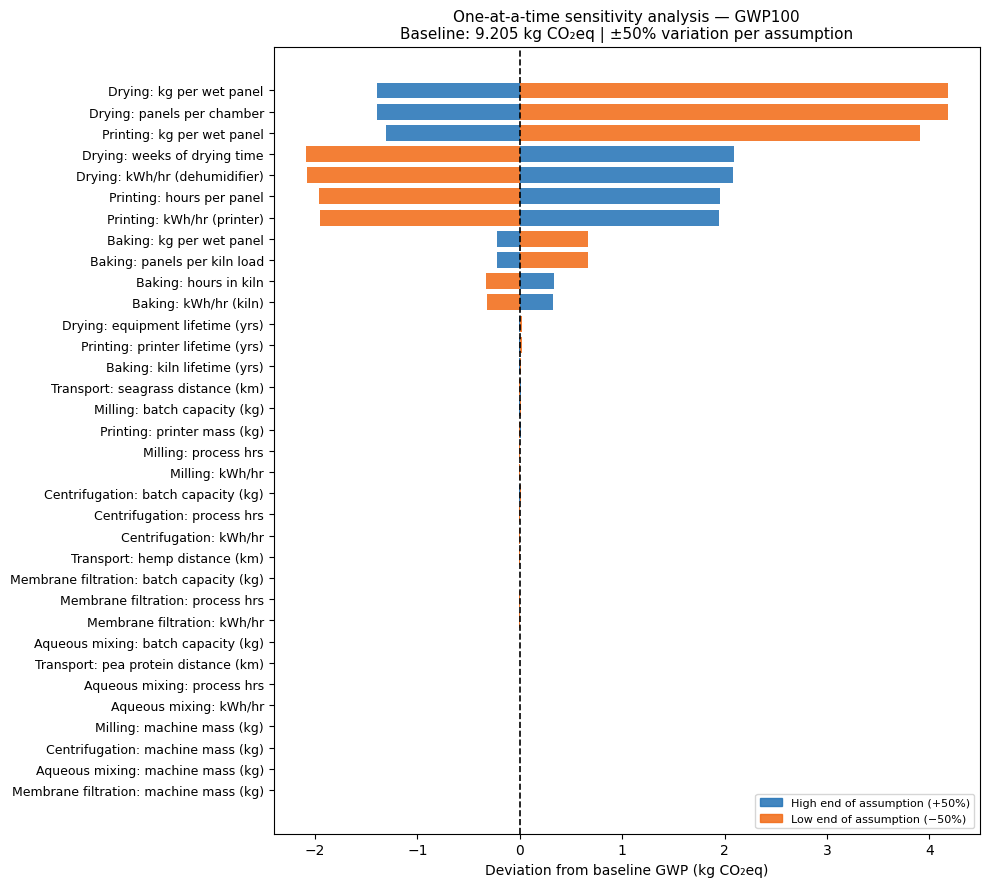

In [28]:
# ── Build summary dataframe ───────────────────────────────────────────────────
rows = []
for param_key, scores in sensitivity_results.items():
    swing = scores['high'] - scores['low']
    rows.append({
        'param':     param_key,
        'label':     ASSUMPTION_LABELS.get(param_key, param_key),
        'low':       scores['low'],
        'high':      scores['high'],
        'swing':     abs(swing),
        'direction': swing,  # positive = high assumption → high impact
    })

df_sa = pd.DataFrame(rows).sort_values('swing', ascending=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, len(df_sa) * 0.22 + 1.5))  # more compact

bar_height = 0.75
y_positions = np.arange(len(df_sa))

for i, row in enumerate(df_sa.itertuples()):
    left  = min(row.low, row.high) - baseline_score
    right = max(row.low, row.high) - baseline_score
    color_right = '#2171b5' if row.direction >= 0 else '#f16913'
    color_left  = '#f16913' if row.direction >= 0 else '#2171b5'
    ax.barh(i, right, left=0, height=bar_height, color=color_right, alpha=0.85)
    ax.barh(i, left,  left=0, height=bar_height, color=color_left,  alpha=0.85)

ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_yticks(y_positions)
ax.set_yticklabels(df_sa['label'], fontsize=9)
ax.set_xlabel('Deviation from baseline GWP (kg CO₂eq)', fontsize=10)
ax.set_title(
    f'One-at-a-time sensitivity analysis — GWP100\n'
    f'Baseline: {baseline_score:.3f} kg CO₂eq | ±{int(VARIATION*100)}% variation per assumption',
    fontsize=11
)

# Fix the legend with explicit patches
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='#2171b5', alpha=0.85, label='High end of assumption (+50%)'),
    mpatches.Patch(color='#f16913', alpha=0.85, label='Low end of assumption (−50%)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

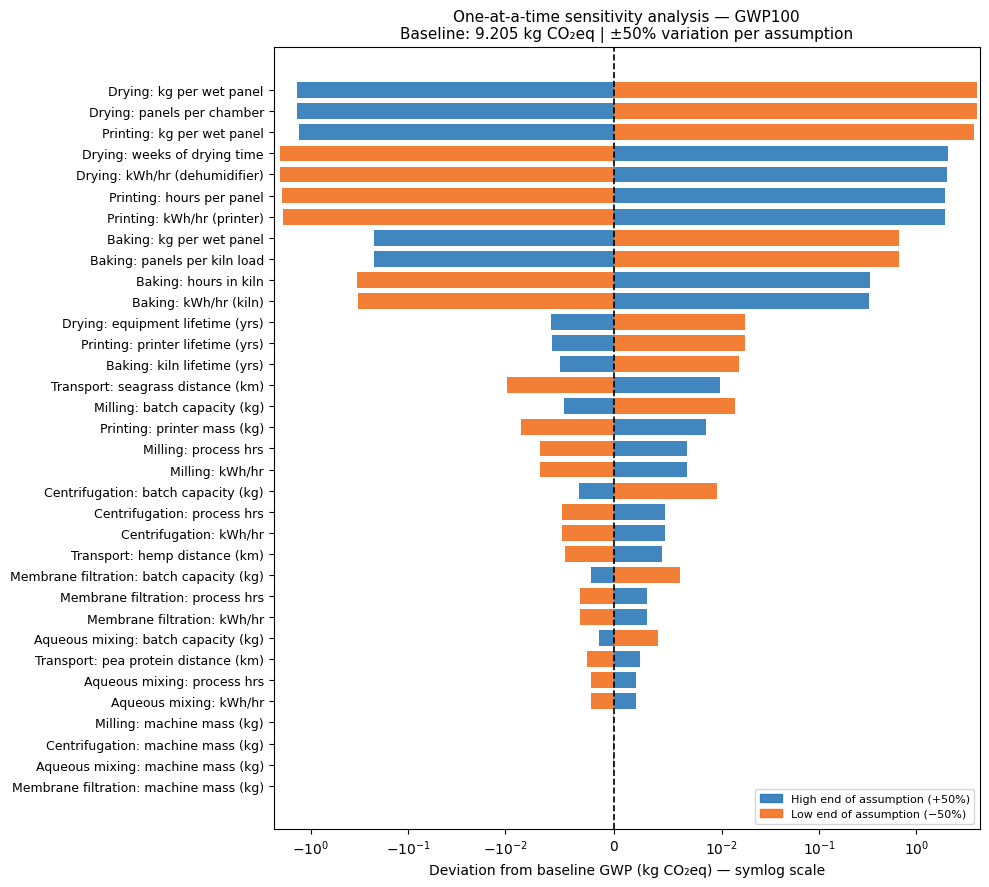

In [29]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, len(df_sa) * 0.22 + 1.5))  # more compact

bar_height = 0.75
y_positions = np.arange(len(df_sa))

for i, row in enumerate(df_sa.itertuples()):
    left  = min(row.low, row.high) - baseline_score
    right = max(row.low, row.high) - baseline_score
    color_right = '#2171b5' if row.direction >= 0 else '#f16913'
    color_left  = '#f16913' if row.direction >= 0 else '#2171b5'
    ax.barh(i, right, left=0, height=bar_height, color=color_right, alpha=0.85)
    ax.barh(i, left,  left=0, height=bar_height, color=color_left,  alpha=0.85)

ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xscale('symlog', linthresh=0.01)
ax.set_yticks(y_positions)
ax.set_yticklabels(df_sa['label'], fontsize=9)
ax.set_xlabel('Deviation from baseline GWP (kg CO₂eq) — symlog scale', fontsize=10)
ax.set_title(
    f'One-at-a-time sensitivity analysis — GWP100\n'
    f'Baseline: {baseline_score:.3f} kg CO₂eq | ±{int(VARIATION*100)}% variation per assumption',
    fontsize=11
)

# Fix the legend with explicit patches
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='#2171b5', alpha=0.85, label='High end of assumption (+50%)'),
    mpatches.Patch(color='#f16913', alpha=0.85, label='Low end of assumption (−50%)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()